# MACHINE LEARNING
## Prediksi Repeat Customer pada Dataset E-Commerce

**Nama:** BAYU DIFA RAMADHAN 05TPLP018  
**Mata Kuliah:** Machine Learning

### Dataset
E-Commerce Sales Customer Analytics

### Tujuan
Membangun model Machine Learning untuk memprediksi apakah seorang customer merupakan repeat customer berdasarkan data transaksi dan karakteristik customer.

### Jenis Machine Learning
Binary Classification

## 1. Import Library

Pada tahap ini dilakukan import beberapa library yang dibutuhkan untuk proses pengolahan data, visualisasi, preprocessing, pembuatan model Machine Learning, dan evaluasi model.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

## 2. Membaca DATASET

Dataset dibaca menggunakan library Pandas. Dataset yang digunakan merupakan data transaksi e-commerce dengan jumlah data yang besar.

Setelah dataset berhasil dibaca, dilakukan pengecekan lima data pertama dan ukuran dataset untuk memastikan data berhasil dimuat dengan benar.

In [4]:
# Membaca dataset dari file CSV yang beradir di folder "data"
file_path = "data/ecommerce_sales_customer_analytics_150k.csv"

df = pd.read_csv(file_path)

print("Ukuran dataset:", df.shape)

display(df.head())

Ukuran dataset: (138116, 46)


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.0,3.0,On Time,NaN,NaN,3.5,Positive,Satisfied with the purchase.,Direct,Default_Campaign,NaN,94,44,5,1350.19,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.0,10.0,On Time,NaN,NaN,3.6,Positive,Good value for money.,Direct,Default_Campaign,NaN,201,171,8,3144.64,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,USA,East,19993,Cash on Delivery,Paid,USD,Express,WH-015,3.0,3.0,On Time,NaN,NaN,4.3,Positive,Good product. Works as expected.,YouTube,NaN,NaN,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina,USA,South,66329,Debit Card,Paid,USD,Express,WH-010,2.0,2.0,On Time,NaN,NaN,3.5,Positive,Satisfied with the purchase.,Email Marketing,NaN,NaN,54,10,2,544.62,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat,India,West,77306,Digital Wallet,Paid,INR,Standard,WH-013,6.0,5.0,Delayed,NaN,NaN,3.0,Neutral,Mixed feelings about this purchase.,Direct,NaN,NaN,278,147,6,2474.52,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [5]:
df.tail()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
138111,ORD-481534,2025-09-27,13:00:50,Completed,Mobile App,CUST-007151,Donna Ruiz,41,Female,Consumer,Loyal,Lake Danielville,New York,USA,East,60282,Credit Card,Paid,USD,Standard,WH-006,7.0,7.0,On Time,NaN,NaN,3.9,Positive,Met my expectations. Would recommend.,Organic Search,Default_Campaign,NaN,22,16,1,212.83,8.84,14.28,6.15,224.42,101.77,116.50,51.91,18182.63,True,14
138112,ORD-487614,2023-07-22,09:13:25,Returned,Social Media,CUST-006686,Jeremy Aguirre,40,Male,Premium,Loyal,Debrafort,California,USA,West,54044,Digital Wallet,Refunded,USD,Standard,WH-001,NaN,NaN,Cancelled,Returned,Size Issue,NaN,NaN,NaN,Instagram,NaN,NaN,0,0,7,2104.32,0.00,147.30,9.18,2260.80,1246.73,1004.89,44.45,10004.74,True,10
138113,ORD-248062,2025-09-08,18:30:32,Cancelled,Mobile App,CUST-017497,Timothy Williams,39,Female,Consumer,Loyal,Mcmillanshire,England,UK,North,59622,PayPal,Failed,GBP,Economy,WH-003,NaN,NaN,Cancelled,NaN,NaN,NaN,NaN,NaN,Direct,NaN,NaN,0,0,8,1861.85,0.00,372.37,26.94,2261.16,970.95,1263.27,55.87,16442.68,True,15
138114,ORD-252033,2022-04-06,14:50:07,Completed,Social Media,CUST-005723,Charles Hanson,46,Female,Consumer,Loyal,South Joshuafort,Ohio,USA,Central,84607,Debit Card,Paid,USD,Same Day,WH-010,1.0,0.0,Delayed,NaN,NaN,3.3,Neutral,Quality could be improved.,Google Ads,NaN,SAVE39,208,7,13,2040.01,174.60,130.58,84.39,2080.38,1042.40,953.59,45.84,8047.00,True,5
138115,ORD-528577,2022-11-23,11:46:00,Completed,Mobile App,CUST-006809,John Miller,28,Male,Consumer,Loyal,Brianview,California,USA,West,88333,Digital Wallet,Paid,USD,Standard,WH-013,5.0,5.0,On Time,NaN,NaN,4.1,Positive,"Product is okay, nothing special but works.",Organic Search,NaN,NaN,157,26,6,1878.14,417.27,102.26,9.09,1572.22,884.46,678.67,43.17,4107.38,True,5


## 3. Data Understanding

Tahap Data Understanding dilakukan untuk mengetahui struktur dan karakteristik dataset.

Beberapa informasi yang diperiksa adalah tipe data, jumlah data, nama kolom, statistik deskriptif, serta distribusi target.

In [6]:
df.info()
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  str    
 1   order_date                138116 non-null  str    
 2   order_time                138116 non-null  str    
 3   order_status              138116 non-null  str    
 4   sales_channel             138116 non-null  str    
 5   customer_id               138116 non-null  str    
 6   customer_name             138116 non-null  str    
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  str    
 9   customer_segment          138116 non-null  str    
 10  customer_type             138116 non-null  str    
 11  customer_city             138116 non-null  str    
 12  customer_state            138116 non-null  str    
 13  customer_country          138116 non-null  str    
 14 

In [7]:
# Cek daftar nama semua kolom di dataset dalam bentuk list
df.columns.tolist()

['order_id',
 'order_date',
 'order_time',
 'order_status',
 'sales_channel',
 'customer_id',
 'customer_name',
 'customer_age',
 'gender',
 'customer_segment',
 'customer_type',
 'customer_city',
 'customer_state',
 'customer_country',
 'region',
 'customer_postal_code',
 'payment_method',
 'payment_status',
 'currency',
 'shipping_method',
 'warehouse',
 'delivery_days',
 'estimated_delivery_days',
 'delivery_status',
 'return_status',
 'return_reason',
 'customer_rating',
 'review_sentiment',
 'customer_review',
 'marketing_channel',
 'campaign_name',
 'coupon_code',
 'loyalty_points_earned',
 'loyalty_points_redeemed',
 'quantity',
 'gross_sales',
 'discount_amount',
 'tax_amount',
 'shipping_cost',
 'net_sales',
 'product_cost',
 'profit',
 'profit_margin_percentage',
 'customer_lifetime_value',
 'is_repeat_customer',
 'customer_order_count']

In [8]:
# Menampilkan statistik deskriptif mencakup seluruh kolom (numerik & kategorikal)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,138116,138116,ORD-301242,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,138116,1826,2025-12-30,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_time,138116,68991,14:55:55,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,138116,4,Completed,113559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,138116,4,Mobile App,55318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,138116,24911,CUST-014687,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_name,138116,21564,John Smith,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,138116.0,NaN,NaN,NaN,45.862681,16.467676,18.0,32.0,46.0,60.0,74.0
gender,138116,3,Female,66439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,138116,4,Consumer,75636,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Mengecek Missing Value

Missing value merupakan data yang memiliki nilai kosong. Pemeriksaan missing value dilakukan untuk mengetahui kolom mana saja yang memiliki data kosong sebelum proses preprocessing dan modeling.

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase Missing": (missing / len(df) * 100).round(2)
})

display(missing_table[missing_table["Jumlah Missing"] > 0])

,Jumlah Missing,Persentase Missing
return_reason,128654,93.15
return_status,128654,93.15
coupon_code,110502,80.01
campaign_name,83233,60.26
customer_review,24557,17.78
customer_rating,24557,17.78
estimated_delivery_days,24557,17.78
delivery_days,24557,17.78
review_sentiment,24557,17.78


## 5. Mengecek Data Duplikat

Pemeriksaan data duplikat dilakukan untuk mengetahui apakah terdapat baris data yang sama. Data duplikat dapat memengaruhi proses pembelajaran model sehingga perlu diperiksa sebelum modeling.

In [10]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


## 6. Data Cleaning

Pada tahap ini data yang memiliki target kosong akan dihapus karena supervised learning membutuhkan nilai target untuk proses pembelajaran.

Missing value pada fitur tidak langsung dihapus karena nantinya akan ditangani menggunakan preprocessing pipeline.

In [11]:
# Menghapus baris yang memiliki nilai kosong (null) pada kolom 'is_repeat_customer'
df = df.dropna(subset=["is_repeat_customer"])

# Menampilkan ukuran dataset (jumlah baris dan kolom) setelah pembersihan
print("Ukuran dataset:", df.shape)

Ukuran dataset: (138116, 46)


## 7. Analisis Target

Target yang digunakan dalam penelitian ini adalah `is_repeat_customer`.

Kolom tersebut menunjukkan apakah customer merupakan pelanggan yang melakukan pembelian berulang atau bukan.

Karena target terdiri dari dua kelas, maka permasalahan Machine Learning ini termasuk Binary Classification.

In [12]:
# Menghitung frekuensi/jumlah kemunculan 
# setiap kategori pada kolom 'is_repeat_customer'
df["is_repeat_customer"].value_counts()

is_repeat_customer
True     137782
False       334
Name: count, dtype: int64

In [13]:
# Menghitung persentase (%) distribusi setiap kategori pada kolom 'is_repeat_customer'
df["is_repeat_customer"].value_counts(normalize=True) * 100

is_repeat_customer
True     99.758174
False     0.241826
Name: proportion, dtype: float64

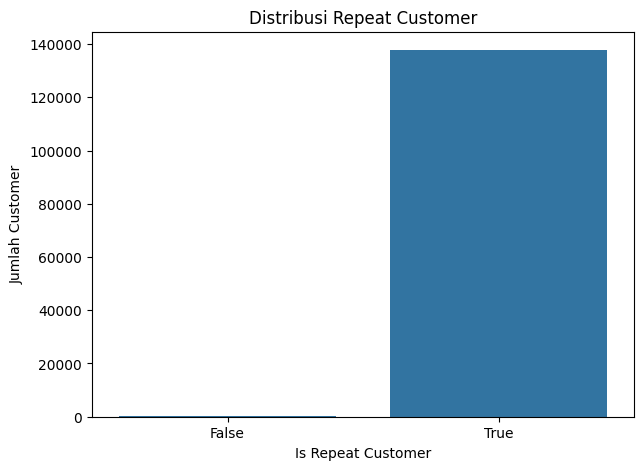

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_repeat_customer"
)

plt.title("Distribusi Repeat Customer")
plt.xlabel("Is Repeat Customer")
plt.ylabel("Jumlah Customer")

plt.show()

## 8. Exploratory Data Analysis

Exploratory Data Analysis atau EDA dilakukan untuk memahami pola dan karakteristik data sebelum membangun model Machine Learning.

Pada tahap ini beberapa variabel numerik divisualisasikan untuk melihat distribusi data.

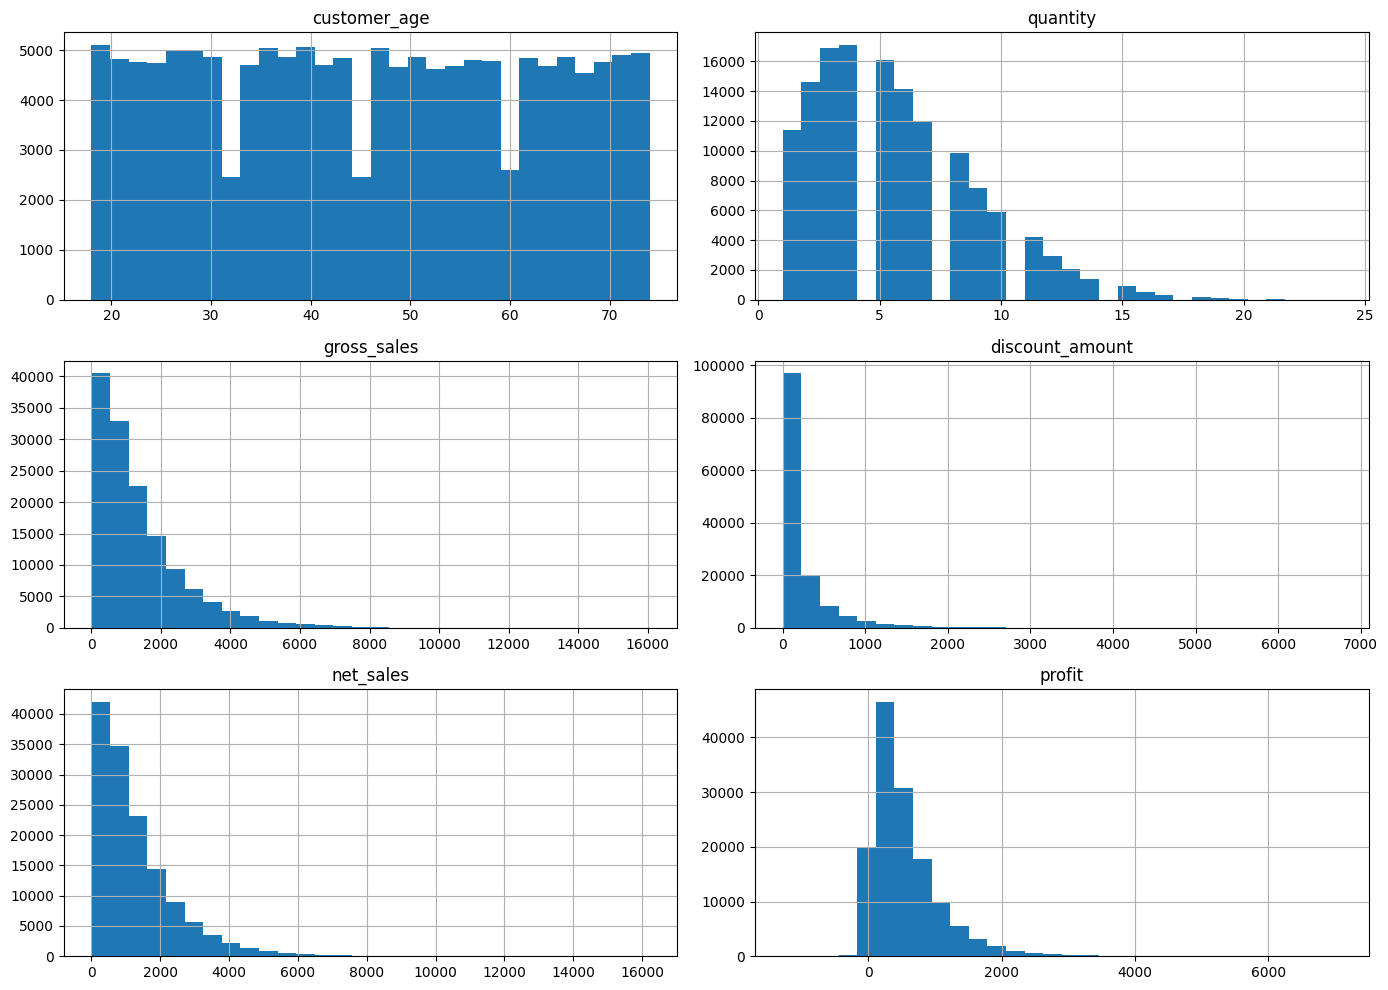

In [15]:
# Membuat daftar kolom numerik yang akan dianalisis
numeric_columns = [
    "customer_age",
    "quantity",
    "gross_sales",
    "discount_amount",
    "net_sales",
    "profit"
]
# Memvisualisasikan distribusi data setiap kolom numerik menggunakan Histogram
df[numeric_columns].hist(
    figsize=(14, 10), # Ukuran grafik (lebar x tinggi)
    bins=30   # Jumlah rentang/batang pada tiap histogram
)
# Merapikan tata letak antar sub-grafik agar tidak saling bertumpukan
plt.tight_layout()
plt.show()

## 9. Analisis Variabel Kategorikal

Beberapa variabel kategorikal dianalisis berdasarkan target untuk melihat apakah terdapat pola tertentu antara kategori customer dengan status repeat customer.

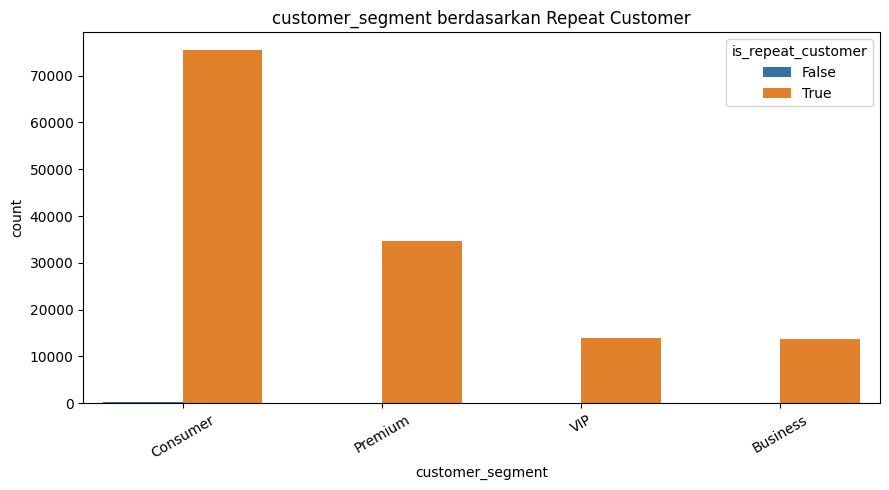

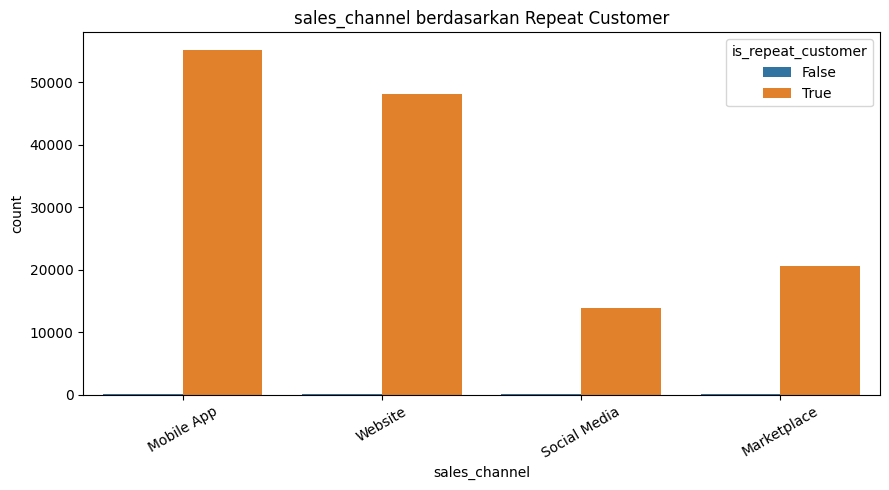

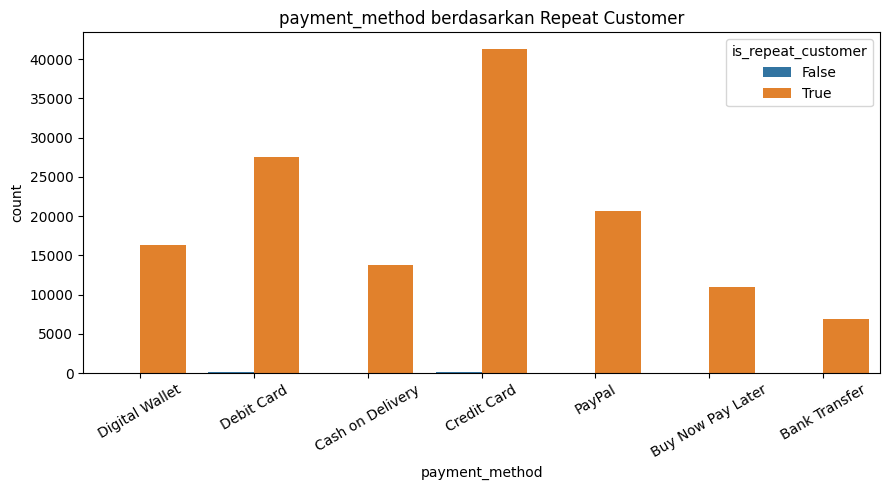

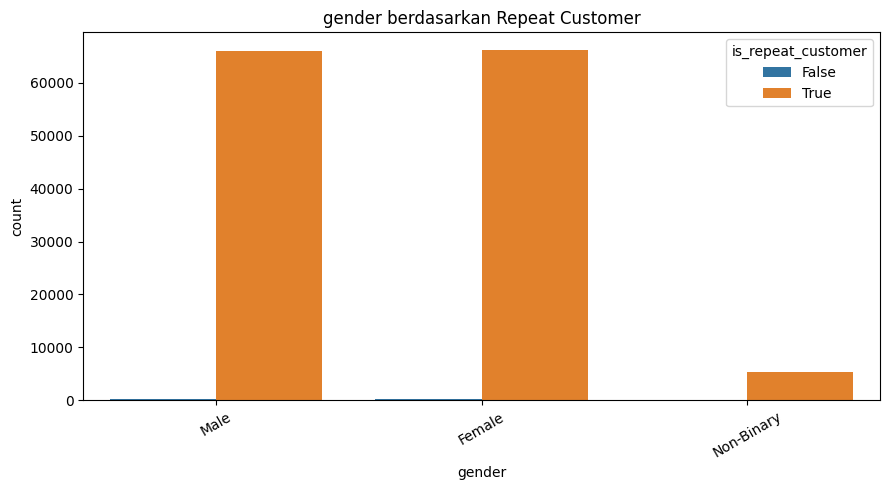

In [16]:
# INSPEKSI STRUKTUR & DESKRIPSI DATASET
categorical_columns = [
    "customer_segment",
    "sales_channel",
    "payment_method",
    "gender"
]
# Melakukan perulangan (looping) untuk setiap kolom di dalam daftar
for column in categorical_columns:

    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="is_repeat_customer"
    )

    plt.title(f"{column} berdasarkan Repeat Customer")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

## 10. Menentukan Target dan Feature

Target merupakan variabel yang ingin diprediksi oleh model. Pada penelitian ini target yang digunakan adalah `is_repeat_customer`.

Feature merupakan variabel yang digunakan model untuk melakukan prediksi.

Beberapa kolom tidak digunakan karena merupakan identitas, teks bebas, atau berpotensi menyebabkan data leakage.

In [17]:
# Menyimpan nama kolom target prediksi ke dalam variabel target
target = "is_repeat_customer"

# Daftar kolom yang dihapus dari data fitur (fitur tidak relevan, ID, dan kolom target)
drop_columns = [
    "is_repeat_customer",
    "order_id",
    "customer_id",
    "customer_name",
    "customer_postal_code",
    "customer_review",
    "coupon_code",
    "campaign_name",
    "customer_order_count",
    "customer_type",
    "customer_lifetime_value"
]

In [18]:
# Membuat DataFrame X (fitur) dengan menghapus kolom-kolom yang ada di drop_columns
X = df.drop(
    columns=drop_columns,
    errors="ignore"
)

# Mengambil kolom target sebagai variabel y dan mengonversinya ke tipe data integer
y = df[target].astype(int)
# Tampilkan jumlah baris dan jumlah kolom
print("Jumlah data:", X.shape[0])
print("Jumlah feature:", X.shape[1])

Jumlah data: 138116
Jumlah feature: 35


In [19]:
# Menampilkan daftar nama kolom yang ada di variabel X dalam bentuk list
X.columns.tolist()

['order_date',
 'order_time',
 'order_status',
 'sales_channel',
 'customer_age',
 'gender',
 'customer_segment',
 'customer_city',
 'customer_state',
 'customer_country',
 'region',
 'payment_method',
 'payment_status',
 'currency',
 'shipping_method',
 'warehouse',
 'delivery_days',
 'estimated_delivery_days',
 'delivery_status',
 'return_status',
 'return_reason',
 'customer_rating',
 'review_sentiment',
 'marketing_channel',
 'loyalty_points_earned',
 'loyalty_points_redeemed',
 'quantity',
 'gross_sales',
 'discount_amount',
 'tax_amount',
 'shipping_cost',
 'net_sales',
 'product_cost',
 'profit',
 'profit_margin_percentage']

## 11. Feature Engineering

Feature engineering dilakukan untuk mengubah data tanggal dan waktu menjadi informasi numerik yang dapat digunakan oleh model.

Tanggal transaksi diubah menjadi tahun, bulan, hari, dan hari dalam minggu. Waktu transaksi diubah menjadi jam transaksi.

In [20]:
# Mengubah format kolom 'order_date' menjadi tipe data datetime
X["order_date"] = pd.to_datetime(
    X["order_date"],
    errors="coerce"
)
# Mengambil komponen angka dari tanggal
X["order_year"] = X["order_date"].dt.year
X["order_month"] = X["order_date"].dt.month
X["order_day"] = X["order_date"].dt.day
X["order_dayofweek"] = X["order_date"].dt.dayofweek

X = X.drop(columns=["order_date"])

In [21]:
# Mengubah kolom 'order_time' ke format datetime
X["order_hour"] = pd.to_datetime(
    X["order_time"],
    errors="coerce"
).dt.hour

X = X.drop(columns=["order_time"])

# Menampilkan 5 baris pertama dari DataFrame X untuk memeriksa hasil prapemrosesan data
X.head()

,order_status,sales_channel,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,marketing_channel,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,order_year,order_month,order_day,order_dayofweek,order_hour
0,Completed,Mobile App,55,Male,Consumer,Lake Williamberg,Texas,USA,South,Digital Wallet,Paid,USD,Standard,WH-003,3.0,3.0,On Time,NaN,NaN,3.5,Positive,Direct,94,44,5,1350.19,477.89,61.07,12.03,945.40,588.33,345.04,36.50,2023,11,6,0,16
1,Completed,Website,26,Male,Premium,Kristyport,Baden-Württemberg,Germany,South,Debit Card,Pending,EUR,Economy,WH-005,10.0,10.0,On Time,NaN,NaN,3.6,Positive,Direct,201,171,8,3144.64,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,2025,12,24,2,1
2,Completed,Mobile App,69,Female,Premium,Singletonhaven,New York,USA,East,Cash on Delivery,Paid,USD,Express,WH-015,3.0,3.0,On Time,NaN,NaN,4.3,Positive,YouTube,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,2021,7,5,0,14
3,Completed,Social Media,65,Male,Consumer,Wigginsstad,North Carolina,USA,South,Debit Card,Paid,USD,Express,WH-010,2.0,2.0,On Time,NaN,NaN,3.5,Positive,Email Marketing,54,10,2,544.62,53.34,34.39,20.85,546.52,277.84,247.83,45.35,2023,1,21,5,7
4,Completed,Social Media,34,Female,Consumer,New Michaelton,Gujarat,India,West,Digital Wallet,Paid,INR,Standard,WH-013,6.0,5.0,Delayed,NaN,NaN,3.0,Neutral,Direct,278,147,6,2474.52,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,2022,5,13,4,9


## 12. Train Test Split

Dataset dibagi menjadi data training dan data testing.

Sebanyak 80% data digunakan untuk training dan 20% digunakan untuk testing.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengetahui kemampuan model terhadap data yang belum pernah dilihat sebelumnya.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (110492, 38)
Data testing : (27624, 38)


## 13. Preprocessing

Preprocessing dilakukan agar data dapat digunakan oleh algoritma Machine Learning.

Untuk data numerik:
- Missing value diisi menggunakan median.
- Data dilakukan standardisasi menggunakan StandardScaler.

Untuk data kategorikal:
- Missing value diisi menggunakan nilai yang paling sering muncul.
- Data kategorikal diubah menjadi angka menggunakan One-Hot Encoding.

In [23]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Fitur numerik:")
print(numeric_features)

print("\nFitur kategorikal:")
print(categorical_features)

Fitur numerik:
['customer_age', 'delivery_days', 'estimated_delivery_days', 'customer_rating', 'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity', 'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost', 'profit', 'profit_margin_percentage']

Fitur kategorikal:
['order_status', 'sales_channel', 'gender', 'customer_segment', 'customer_city', 'customer_state', 'customer_country', 'region', 'payment_method', 'payment_status', 'currency', 'shipping_method', 'warehouse', 'delivery_status', 'return_status', 'return_reason', 'review_sentiment', 'marketing_channel']


In [24]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [25]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 14. Modeling — Logistic Regression

Logistic Regression merupakan salah satu algoritma klasifikasi yang digunakan untuk memprediksi kelas berdasarkan probabilitas.

Pada penelitian ini Logistic Regression digunakan sebagai salah satu model pembanding.

In [27]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

y_pred_logistic = logistic_model.predict(
    X_test
)

## 15. Evaluasi Logistic Regression

Model Logistic Regression dievaluasi menggunakan accuracy, precision, recall, dan F1-score.

In [28]:
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1-Score :", f1_score(y_test, y_pred_logistic))

Accuracy : 0.9794019693020561
Precision: 0.9976030680728667
Recall   : 0.981710636136009
F1-Score : 0.9895930498399634


## 16. Modeling — Decision Tree

Decision Tree merupakan algoritma klasifikasi yang menggunakan struktur seperti pohon untuk melakukan pengambilan keputusan berdasarkan fitur yang tersedia.

In [29]:
decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree_model.predict(
    X_test
)

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-Score :", f1_score(y_test, y_pred_tree))

Accuracy : 0.8740949898638865
Precision: 0.9975205587007727
Recall   : 0.8759661791922198
F1-Score : 0.9328000618285802


## 17. Modeling — Random Forest

Random Forest merupakan algoritma ensemble yang menggabungkan banyak Decision Tree.

Model ini digunakan sebagai model pembanding karena mampu menangani hubungan yang kompleks antara feature dan target.

In [31]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    X_test
)

## 18. Evaluasi Random Forest

Random Forest dievaluasi menggunakan beberapa metrik klasifikasi untuk mengetahui kemampuan model dalam melakukan prediksi.

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9930133217492035
Precision: 0.9975634591606662
Recall   : 0.9954276590340022
F1-Score : 0.9964944146762329


## 19. Perbandingan Model

Pada tahap ini performa ketiga algoritma dibandingkan menggunakan Accuracy, Precision, Recall, dan F1-Score.

F1-Score digunakan sebagai salah satu pertimbangan utama karena memperhatikan precision dan recall secara bersamaan.

In [33]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

results = results.sort_values(
    by="F1-Score",
    ascending=False
)

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.993013,0.997563,0.995428,0.996494
0,Logistic Regression,0.979402,0.997603,0.981711,0.989593
1,Decision Tree,0.874095,0.997521,0.875966,0.932800


## 20. Visualisasi Perbandingan Model

Hasil evaluasi model divisualisasikan untuk mempermudah perbandingan performa masing-masing algoritma.

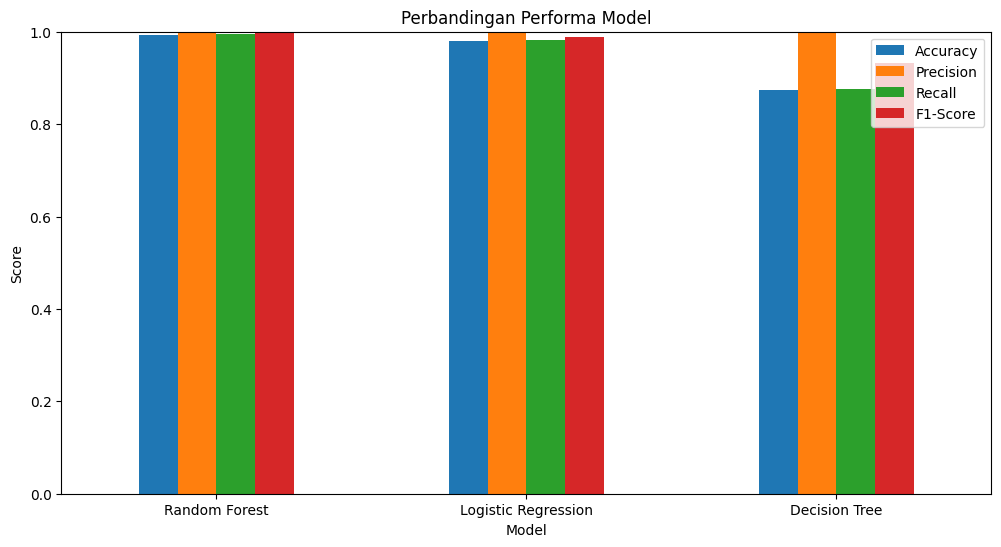

In [34]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()

plt.show()

## 21. Menentukan Model Terbaik

Model terbaik ditentukan berdasarkan nilai F1-Score tertinggi.

Setelah hasil model diperoleh, model dengan F1-Score tertinggi digunakan untuk evaluasi lebih lanjut menggunakan classification report dan confusion matrix.

In [35]:
best_model_name = results.iloc[0]["Model"]

print("Model terbaik:", best_model_name)
print("F1-Score:", results.iloc[0]["F1-Score"])

Model terbaik: Random Forest
F1-Score: 0.9964944146762329


## 22. Classification Report

Classification report memberikan informasi lebih detail mengenai precision, recall, F1-score, dan jumlah data pada masing-masing kelas.

In [36]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    y_pred_best = y_pred_logistic

elif best_model_name == "Decision Tree":
    best_model = decision_tree_model
    y_pred_best = y_pred_tree

else:
    best_model = random_forest_model
    y_pred_best = y_pred_rf

In [37]:
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "Not Repeat",
            "Repeat"
        ]
    )
)

              precision    recall  f1-score   support

  Not Repeat       0.00      0.00      0.00        67
      Repeat       1.00      1.00      1.00     27557

    accuracy                           0.99     27624
   macro avg       0.50      0.50      0.50     27624
weighted avg       1.00      0.99      0.99     27624



## 23. Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi benar dan salah dari masing-masing kelas.

Confusion Matrix terdiri dari True Positive, True Negative, False Positive, dan False Negative.

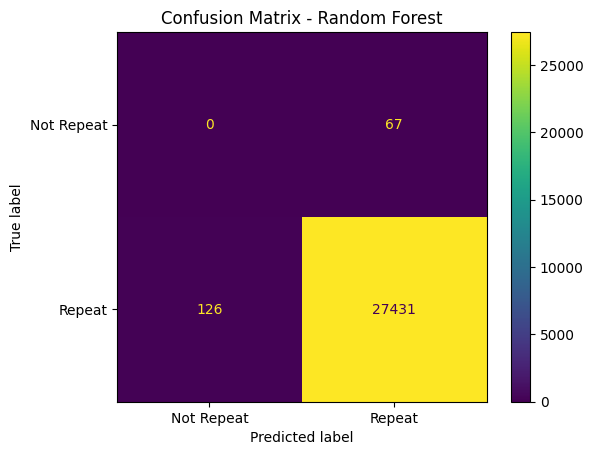

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Repeat",
        "Repeat"
    ]
)

disp.plot(values_format="d")

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

## 24. Cross Validation

Cross Validation digunakan untuk mengetahui kestabilan performa model pada beberapa pembagian data.

Metode yang digunakan adalah 5-Fold Stratified Cross Validation. Data dibagi menjadi lima bagian dan proses training/testing dilakukan secara bergantian.

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [40]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

In [41]:
print("F1-Score setiap fold:", cv_scores)
print("Rata-rata F1-Score:", cv_scores.mean())
print("Standar Deviasi:", cv_scores.std())

F1-Score setiap fold: [0.99647619 0.99549075 0.99543595 0.99222911 0.99756859]
Rata-rata F1-Score: 0.9954401163845329
Standar Deviasi: 0.0017842058451238833


# 25. Kesimpulan

Berdasarkan proses Machine Learning yang telah dilakukan, dataset E-Commerce Sales Customer Analytics berhasil melalui beberapa tahapan, yaitu data understanding, data cleaning, exploratory data analysis, feature selection, feature engineering, preprocessing, train-test split, modeling, dan evaluasi.

Target yang digunakan adalah `is_repeat_customer`. Karena target memiliki dua kelas, yaitu repeat customer dan bukan repeat customer, maka masalah Machine Learning yang digunakan adalah binary classification.

Tiga algoritma yang digunakan adalah Logistic Regression, Decision Tree, dan Random Forest. Performa ketiga model dibandingkan menggunakan Accuracy, Precision, Recall, dan F1-Score.

Model terbaik dipilih berdasarkan nilai F1-Score tertinggi. Hasil Confusion Matrix dan Classification Report kemudian digunakan untuk melihat performa model secara lebih detail.

Cross Validation juga dilakukan untuk mengetahui kestabilan performa model pada beberapa pembagian data.

Secara keseluruhan, tahapan yang dilakukan menunjukkan bagaimana dataset transaksi e-commerce dapat digunakan untuk membangun model Machine Learning untuk memprediksi repeat customer.